# 02 — Results Analysis
Loads the experiment JSONs written by `src.train`, reproduces the headline table, inspects LambdaMART feature importance, and breaks metrics out by eval slice (random vs hard negatives, cold vs active users).

Run the experiments first:
```
make run-all && make evaluate
```

In [1]:
import sys, os, glob, json
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.evaluate import load_results, _headline_frame, _long_frame
PALETTE = ['#2a78d6','#eb6834','#1baf7a','#eda100','#e87ba4']
plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.25,'axes.axisbelow':True})
results = load_results(__import__('pathlib').Path('../results'))
print(f'{len(results)} experiments loaded')

6 experiments loaded


## Headline table (test pool, random negatives)

In [2]:
head = _headline_frame(results)
head[['experiment','recall@200','ndcg@10','mrr@10','map@10','recall@10']].round(4)

,experiment,recall@200,ndcg@10,mrr@10,map@10,recall@10
0,als_lambdamart,0.4245,0.5089,0.5309,0.3933,0.6924
1,two_tower_lambdamart,0.4552,0.5048,0.5129,0.3897,0.6957
4,two_tower_neural:listnet,0.4552,0.4538,0.4675,0.3449,0.6310
3,two_tower_neural:listmle,0.4552,0.4450,0.4497,0.3386,0.6235
2,two_tower_neural:bpr,0.4552,0.4395,0.4428,0.3281,0.6294
5,two_tower_neural:ranknet,0.4552,0.4339,0.4355,0.3214,0.6277


## Stage-1 retrieval ceiling
Recall@200 upper-bounds what stage-2 can recover — items retrieval misses can never be ranked back.

In [3]:
ret = {r['retriever']: r['retrieval'] for r in results}
pd.DataFrame(ret).T.round(4)

,recall@100,recall@200
als,0.3176,0.4245
two_tower,0.3317,0.4552


## LambdaMART feature importance
Note where the stage-1 retrieval score lands — passing it into stage-2 is a standard, high-value cross feature.

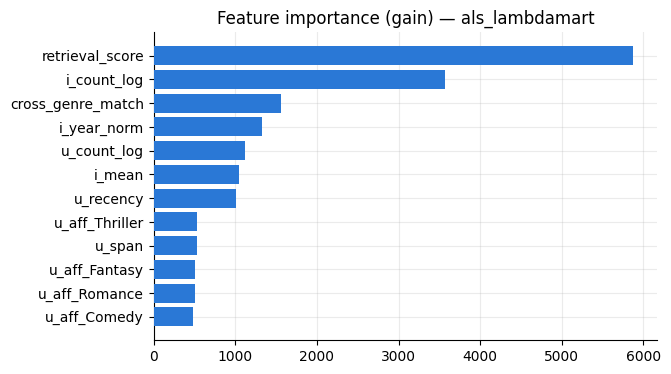

In [4]:
imp = None
for r in results:
    if r.get('feature_importance'):
        imp = r; break
if imp:
    fi = pd.Series(imp['feature_importance']).sort_values(ascending=False).head(12)
    fig, ax = plt.subplots(figsize=(6.5,4))
    ax.barh(fi.index[::-1], fi.values[::-1], color=PALETTE[0], zorder=3)
    ax.set_title(f"Feature importance (gain) — {imp['experiment']}"); plt.show()
else:
    print('No tree-based experiment with feature importance found.')

## Loss ablation: listwise vs pairwise (neural ranker)

In [5]:
neu = [r for r in results if r['ranker']=='neural' and r.get('loss')]
if neu:
    df = pd.DataFrame([{'loss':r['loss'],'family':r['loss_family'],
                        'ndcg@10':r['metrics_random']['ndcg@10'],
                        'map@10':r['metrics_random']['map@10']} for r in neu])
    display(df.sort_values('ndcg@10', ascending=False).round(4))
else:
    print('Run configs/two_tower_neural.yaml for the ablation.')

,loss,family,ndcg@10,map@10
2,listnet,listwise,0.4538,0.3449
1,listmle,listwise,0.4450,0.3386
0,bpr,pairwise,0.4395,0.3281
3,ranknet,pairwise,0.4339,0.3214


## Slice breakdown: hard negatives & cold-start
Popularity-based hard negatives and low-history users are where quality drops.

In [6]:
long = _long_frame(results)
piv = (long[(long.metric=='ndcg')&(long.k==10)]
       .pivot_table(index='experiment', columns='slice', values='value'))
piv = piv[[c for c in ['random','hard','cold','active'] if c in piv.columns]]
piv.round(4)

slice,random,hard,cold,active
experiment,,,,
als_lambdamart,0.5089,0.2786,0.5723,0.4795
two_tower_lambdamart,0.5048,0.3086,0.5750,0.4723
two_tower_neural:bpr,0.4395,0.2537,0.5206,0.4020
two_tower_neural:listmle,0.4450,0.1621,0.5185,0.4109
two_tower_neural:listnet,0.4538,0.2544,0.5366,0.4155
two_tower_neural:ranknet,0.4339,0.2496,0.5150,0.3963


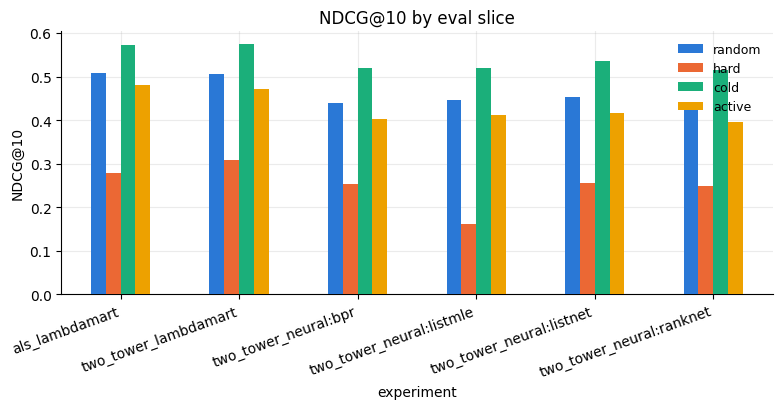

In [7]:
ax = piv.plot(kind='bar', figsize=(8,4.2), color=PALETTE, zorder=3)
ax.set_ylabel('NDCG@10'); ax.set_title('NDCG@10 by eval slice')
ax.legend(frameon=False, fontsize=9); plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

**Reading the results**
- The stronger retriever lifts Recall@200 (a higher stage-2 ceiling).
- LambdaMART on engineered tabular features is a hard baseline for a small MLP.
- Every model degrades on the hard-negative and cold-start slices — the honest picture.